
# Segmentation
* apo
* fasc


### 実行環境
* `googlecolab`
* `kaggle notebook`（未確認）

モデルを保存する

```
run_segmentation()
      │
      ├── apo
      │    ├ learn
      │    ├ apo_model.pth
      │    ├ Dice / IoU
      │    └ visualization
      │
      └── fasc
           ├ learn
           ├ fasc_model.pth
           ├ Dice / IoU
           └ visualization
```



# Related notebooks(関連するnotebook)
|name|github|kaggle|
|-----|-----|-----|
|Data confirmation file(データ確認ファイル)|[study.ipynb](https://github.com/kenkenkengo0421/Muscle_Architecture_in_Ultrasound_Data/blob/main/study.ipynb)|https://www.kaggle.com/code/nagatakengo/study|
|Consistency investigation regarding image size differences(画像サイズ違いについての整合調査)|[Imagesize_investigation.ipynb](https://github.com/kenkenkengo0421/Muscle_Architecture_in_Ultrasound_Data/blob/main/Imagesize_investigation.ipynb)|https://www.kaggle.com/code/nagatakengo/imagesize-investigation|


Mounted at /content/drive
実行開始時間: 2026-09-18 23:38:22 JST
device: cuda
GPU: NVIDIA A100-SXM4-80GB

apo pos_weight=1.5 segmentation
全データ: 1048
train: 838
validation: 210
image min: tensor(0.)
image max: tensor(1.)
mask unique: tensor([0., 1.])
images shape: torch.Size([4, 3, 512, 768])
masks shape: torch.Size([4, 1, 512, 768])
masks unique: tensor([0., 1.])
device: cuda
pos_weight: 1.5
apo pos_weight=1.5 epoch: 1/5
train loss: 0.15031180014224782
validation loss: 0.09473064921441532
validation Dice: 0.45097418237478887
apo pos_weight=1.5 epoch: 2/5
train loss: 0.08893258347751702
validation loss: 0.08278463653155736
validation Dice: 0.5242377780984326
apo pos_weight=1.5 epoch: 3/5
train loss: 0.08255772386857604
validation loss: 0.07611085211946851
validation Dice: 0.5985308874358083
apo pos_weight=1.5 epoch: 4/5
train loss: 0.07537462436071728
validation loss: 0.07233404265273186
validation Dice: 0.6316635629043685
apo pos_weight=1.5 epoch: 5/5
train loss: 0.07054776687237271
validatio

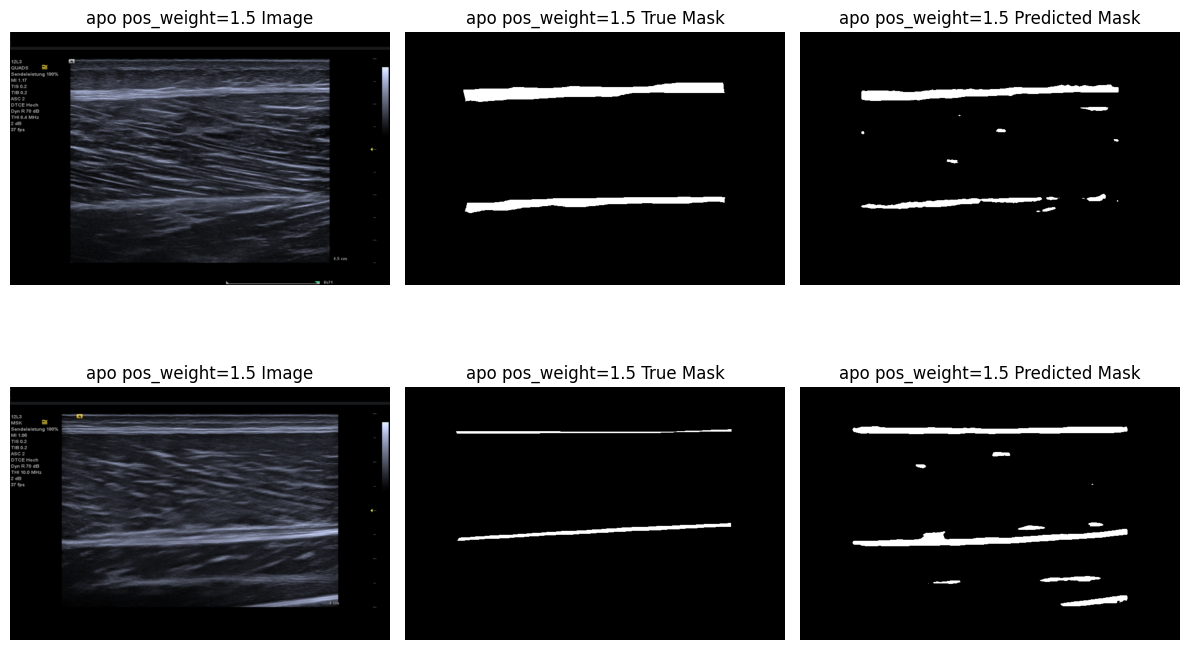


fasc pos_weight=15 segmentation
全データ: 2761
train: 2208
validation: 553
image min: tensor(0.)
image max: tensor(1.)
mask unique: tensor([0., 1.])
images shape: torch.Size([4, 3, 512, 768])
masks shape: torch.Size([4, 1, 512, 768])
masks unique: tensor([0., 1.])
device: cuda
pos_weight: 15
fasc pos_weight=15 epoch: 1/5
train loss: 0.1583424357029245
validation loss: 0.09728268009445727
validation Dice: 0.17437080064318838
fasc pos_weight=15 epoch: 2/5
train loss: 0.11384208352251006
validation loss: 0.08611698117819934
validation Dice: 0.1848962204685664
fasc pos_weight=15 epoch: 3/5
train loss: 0.08428728351524721
validation loss: 0.07463484473983734
validation Dice: 0.2035534394821678
fasc pos_weight=15 epoch: 4/5
train loss: 0.07847638868396103
validation loss: 0.07084403534013012
validation Dice: 0.2001224013977951
fasc pos_weight=15 epoch: 5/5
train loss: 0.0749738456570017
validation loss: 0.0725403140006513
validation Dice: 0.23504655798903787

fasc pos_weight=15
train loss: 0.07

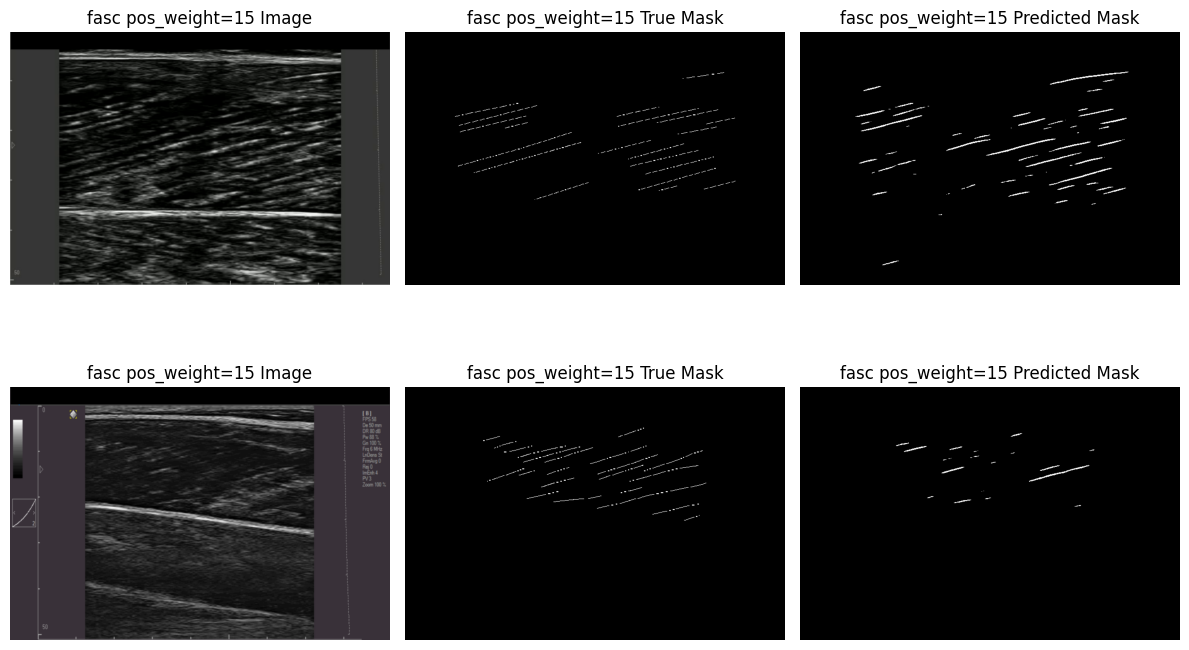


apo pos_weight comparison

pos_weight: 1.5
train loss: 0.07054776687237271
validation loss: 0.0688623023884637
best epoch: 5
best validation Dice: 0.6441354786426546
best threshold: 0.58
Dice: 0.6508847927339572
IoU: 0.48245308423508415
validation pred masks 1: 2797230.0
validation true masks 1: 2359910.0

fasc pos_weight comparison

pos_weight: 15
train loss: 0.0749738456570017
validation loss: 0.0725403140006513
best epoch: 5
best validation Dice: 0.23504655798903787
best threshold: 0.58
Dice: 0.2419607180919769
IoU: 0.13763100778349716
validation pred masks 1: 1180333.0
validation true masks 1: 608073.0

実行開始時間: 2026-09-18 23:38:22 JST
すべての処理が終了した時間: 2026-09-19 00:03:00 JST
総処理時間: 00:24:37
Google Driveへの書き込みを確定します
Google Driveへの保存が完了しました
Colabランタイムを切断します


In [ ]:
"""
import sys
sys.path.append("/kaggle/input/competitions/umud-challenge-muscle-architecture-in-ultrasound-data")
!pip uninstall -y -q torch torchvision torchaudio > /dev/null 2>&1
!pip install -q --no-cache-dir \
    torch==2.10.0 \
    torchvision==0.25.0 \
    torchaudio==2.10.0 \
    --index-url https://download.pytorch.org/whl/cu126 \
    > /dev/null 2>&1
"""

from PIL import Image
import matplotlib.pyplot as plt
import os
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from torch.utils.data import random_split
import torch.nn as nn
import time
from datetime import datetime, timezone, timedelta

try:
    from google.colab import drive
    from google.colab import runtime
    is_colab = True
except ImportError:
    is_colab = False

if is_colab:

    drive.mount("/content/drive")

    !mkdir -p /content/my_dataset
    !unzip -q -o "/content/drive/MyDrive/colab/UMUD/umud-challenge-muscle-architecture-in-ultrasound-data.zip" -d /content/my_dataset/

    data_dir = "/content/my_dataset"
    model_output_dir = "/content/drive/MyDrive/colab/UMUD"

elif os.path.exists("/kaggle/input"):

    data_dir = "/kaggle/input/competitions/umud-challenge-muscle-architecture-in-ultrasound-data"
    model_output_dir = "/kaggle/working"

else:

    raise RuntimeError("ColabまたはKaggle環境ではありません")


jst = timezone(timedelta(hours=9))
execution_start_datetime = datetime.now(jst)
execution_start_time = time.perf_counter()

print("=============================================")
print(
    "実行開始時間:",
    execution_start_datetime.strftime("%Y-%m-%d %H:%M:%S JST")
)
print("=============================================")


# 修正
device_check = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print("device:", device_check)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


def load_apo_binary_mask(mask_dir, file_name):
    """
    apo mask を
    背景=0
    aponeurosis=1
    の二値配列に変換する
    """
    mask = Image.open(os.path.join(mask_dir, file_name))
    mask_array = np.array(mask)

    if mask.mode == "P":
        binary_mask = (mask_array == 0).astype(np.uint8)
    elif mask.mode == "L":
        binary_mask = (mask_array == 255).astype(np.uint8)
    else:
        raise ValueError(f"未対応のmodeです: {mask.mode}")

    return binary_mask


def load_fasc_binary_mask(mask_dir, file_name):
    """
    fasc mask を
    背景=0
    fascicle=1
    の二値配列に変換する
    """
    mask = Image.open(os.path.join(mask_dir, file_name))
    mask_array = np.array(mask)

    if mask.mode == "L":
        binary_mask = (mask_array == 255).astype(np.uint8)
    else:
        raise ValueError(f"未対応のmodeです: {mask.mode}")

    return binary_mask


def resize_with_padding(image, mask, target_size=(768, 512)):
    """
    image と mask の縦横比を維持したまま縮小し、
    target_size まで余白を追加する
    """

    target_width, target_height = target_size
    original_width, original_height = image.size

    scale = min(target_width / original_width, target_height / original_height)
    new_width = int(original_width * scale)
    new_height = int(original_height * scale)

    # image を縮小
    image = image.resize((new_width, new_height), resample=Image.Resampling.BILINEAR)

    # mask を同じサイズへ縮小
    mask = mask.resize((new_width, new_height), resample=Image.Resampling.NEAREST)

    # 余白の位置
    left = (target_width - new_width) // 2
    top = (target_height - new_height) // 2

    # image 用canvas
    image_canvas = Image.new(image.mode, target_size, 0)

    # mask 用canvas
    mask_canvas = Image.new("L", target_size, 0)

    # 同じ位置へ配置
    image_canvas.paste(image, (left, top))
    mask_canvas.paste(mask, (left, top))

    return image_canvas, mask_canvas


class SegmentationDataset(Dataset):

    def __init__(self, image_dir, mask_dir, mask_loader):

        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.mask_loader = mask_loader
        self.image_files = sorted([
            f for f in os.listdir(image_dir)
            if f.lower().endswith(
                (".tif", ".tiff", ".png", ".jpg", ".jpeg")
            )
        ])

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, index):

        file_name = self.image_files[index]
        image_path = os.path.join(self.image_dir, file_name)
        image = Image.open(image_path).convert("RGB")
        mask = self.mask_loader(self.mask_dir, file_name)

        #maskとimageをサイズ揃える
        mask = Image.fromarray(mask)
        mask = mask.resize(image.size, resample=Image.Resampling.NEAREST)

        image, mask = resize_with_padding(image, mask, target_size=(768, 512))

        # image → numpy → Tensor
        image = np.array(image)
        image = torch.from_numpy(image).float() / 255.0
        image = image.permute(2, 0, 1)

        # mask → numpy → Tensor
        mask = np.array(mask)
        mask = torch.from_numpy(mask).float()
        mask = mask.unsqueeze(0)

        return image, mask


class DoubleConv(nn.Module):

    def __init__(self, in_channels, out_channels):

        super().__init__()

        self.conv = nn.Sequential(

            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.conv(x)


class UNet(nn.Module):

    def __init__(self):
        super().__init__()

        # Encoder
        self.enc1 = DoubleConv(3, 64)
        self.pool1 = nn.MaxPool2d(2)

        self.enc2 = DoubleConv(64, 128)
        self.pool2 = nn.MaxPool2d(2)

        self.enc3 = DoubleConv(128, 256)
        self.pool3 = nn.MaxPool2d(2)

        self.enc4 = DoubleConv(256, 512)
        self.pool4 = nn.MaxPool2d(2)

        # Bottleneck
        self.bottleneck = DoubleConv(512, 1024)

        # Decoder
        self.up4 = nn.ConvTranspose2d(1024, 512, kernel_size=2, stride=2)
        self.dec4 = DoubleConv(1024, 512)
        self.up3 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.dec3 = DoubleConv(512, 256)
        self.up2 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.dec2 = DoubleConv(256, 128)
        self.up1 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.dec1 = DoubleConv(128, 64)

        # 出力
        self.output = nn.Conv2d(64, 1, kernel_size=1)

    def forward(self, x):

        enc1 = self.enc1(x)
        enc2 = self.enc2(self.pool1(enc1))
        enc3 = self.enc3(self.pool2(enc2))
        enc4 = self.enc4(self.pool3(enc3))

        bottleneck = self.bottleneck(self.pool4(enc4))

        dec4 = self.up4(bottleneck)
        dec4 = torch.cat((dec4, enc4), dim=1)
        dec4 = self.dec4(dec4)

        dec3 = self.up3(dec4)
        dec3 = torch.cat((dec3, enc3), dim=1)
        dec3 = self.dec3(dec3)

        dec2 = self.up2(dec3)
        dec2 = torch.cat((dec2, enc2), dim=1)
        dec2 = self.dec2(dec2)

        dec1 = self.up1(dec2)
        dec1 = torch.cat((dec1, enc1), dim=1)
        dec1 = self.dec1(dec1)

        return self.output(dec1)


# Dataset作成 → 学習 → 保存 → Dice / IoU → 可視化
def run_segmentation(
    image_dir,
    mask_dir,
    mask_loader,
    model_save_name,
    label_name,
    lr=0.001,
    batch_size=2,
    num_epochs=5,
    pos_weight=None
):

    print()
    print("=============================================")
    print(f"{label_name} segmentation")
    print("=============================================")

    # Dataset

    dataset = SegmentationDataset(image_dir, mask_dir, mask_loader)
    train_size = int(len(dataset) * 0.8)
    val_size = (len(dataset) - train_size)

    generator = (torch.Generator().manual_seed(42))
    train_dataset, val_dataset = random_split(dataset, [train_size, val_size], generator=generator)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)


    print("=============================================")
    print("全データ:", len(dataset))
    print("train:", len(train_dataset))
    print("validation:", len(val_dataset))

    dataset_loader = DataLoader(dataset, batch_size=4, shuffle=True)

    images, masks = next(iter(dataset_loader))

    print("=============================================")
    print("image min:", images.min())
    print("image max:", images.max())
    print("mask unique:", torch.unique(masks))

    print("=============================================")
    print("images shape:", images.shape)
    print("masks shape:", masks.shape)
    print("masks unique:", torch.unique(masks))


    #設定

    device = torch.device(
        "cuda"
        if torch.cuda.is_available()
        else "cpu"
    )

    print("device:", device)

    torch.manual_seed(42)
    torch.cuda.manual_seed_all(42)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    model = UNet()                                      #モデル
    model = model.to(device)

    if pos_weight is None:
        criterion = nn.BCEWithLogitsLoss()                  #U-Netの予測─正解maskとどれくらい違うか計算-loss
    else:
        pos_weight_tensor = torch.tensor([pos_weight], dtype=torch.float32, device=device)
        criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight_tensor)
        print("pos_weight:", pos_weight)

    optimizer = torch.optim.Adam(
        model.parameters(),                             #U-Netの学習対象パラメータ
        lr=lr                                           #1回の更新幅
    )

    best_val_dice = -1
    best_val_loss = None
    best_train_loss = None
    best_epoch = 0


    #学習

    for epoch in range(num_epochs):
        model.train()
        total_loss = 0

        for images, masks in train_loader:

            images = images.to(device)
            masks = masks.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, masks)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        train_loss = (total_loss / len(train_loader))

        # validation

        model.eval()
        val_total_loss = 0

        intersection_total = 0
        pred_total = 0
        true_total = 0

        with torch.no_grad():
            for images, masks in val_loader:
                images = images.to(device)
                masks = masks.to(device)
                outputs = model(images)
                loss = criterion(outputs, masks)
                val_total_loss += loss.item()

                pred_probs = torch.sigmoid(outputs)
                pred_masks = (pred_probs >= 0.5).float()

                intersection_total += (pred_masks * masks).sum().item()
                pred_total += pred_masks.sum().item()
                true_total += masks.sum().item()

        val_loss = (val_total_loss / len(val_loader))

        val_dice = (2 * intersection_total) / (pred_total + true_total)

        print("=============================================")
        print(
            f"{label_name} "
            f"epoch: {epoch + 1}/{num_epochs}"
        )
        print("train loss:", train_loss)
        print("validation loss:", val_loss)
        print("validation Dice:", val_dice)

        #Dice最大のモデルを保存
        if val_dice > best_val_dice:
            best_val_dice = val_dice
            best_val_loss = val_loss
            best_train_loss = train_loss
            best_epoch = epoch + 1
            torch.save(model.state_dict(), model_save_name)


    # 学習結果保存

    print(f"""
=================================================
{label_name}
train loss: {best_train_loss}
validation loss: {best_val_loss}
best epoch: {best_epoch}
best validation Dice: {best_val_dice}
=================================================
""")


    with open("log.txt", "a") as f:
        f.write(f"{label_name}\n")
        f.write(f"train loss: {best_train_loss}\n")
        f.write(f"validation loss: {best_val_loss}\n")
        f.write(f"best epoch: {best_epoch}\n")
        f.write(f"best validation Dice: {best_val_dice}\n")

    print(f"{model_save_name} を保存しました")

    # 保存済みモデルを読み込む
    model = UNet()
    model.load_state_dict(torch.load(model_save_name, map_location=device))
    model = model.to(device)
    model.eval()

    print(f"{label_name}_modelを読み込みました")
    print("device:", device)

    # validationデータでthresholdを比較する
    thresholds = [0.52, 0.54, 0.55, 0.56, 0.58]

    best_threshold = None
    best_dice = -1
    best_iou = None
    best_pred_total = None
    best_true_total = None

    print("=============================================")
    print(f"{label_name} threshold comparison")
    print("=============================================")

    for threshold in thresholds:

        intersection_total = 0
        pred_total = 0
        true_total = 0
        union_total = 0

        with torch.no_grad():
            for images, masks in val_loader:
                images = images.to(device)
                masks = masks.to(device)
                outputs = model(images)

                # logits → 確率
                pred_probs = torch.sigmoid(outputs)

                pred_masks = (pred_probs >= threshold).float()

                intersection_total += (pred_masks * masks).sum().item()
                pred_total += pred_masks.sum().item()
                true_total += masks.sum().item()
                union_total += (((pred_masks + masks) > 0).float().sum().item())

        dice = (2 * intersection_total) / (pred_total + true_total)
        iou = (intersection_total / union_total)

        print()
        print("threshold:", threshold)
        print("Dice:", dice)
        print("IoU:", iou)
        print("validation pred masks 1:", pred_total)
        print("validation true masks 1:", true_total)

        if dice > best_dice:
            best_threshold = threshold
            best_dice = dice
            best_iou = iou
            best_pred_total = pred_total
            best_true_total = true_total

    dice = best_dice
    iou = best_iou
    pred_total = best_pred_total
    true_total = best_true_total

    print()
    print("=============================================")
    print(f"{label_name} best threshold:", best_threshold)
    print(f"{label_name} Dice:", dice)
    print(f"{label_name} IoU:", iou)
    print(f"{label_name} validation pred masks 1:", pred_total)
    print(f"{label_name} validation true masks 1:", true_total)

    # 予測maskの可視化
    images, masks = next(iter(val_loader))

    images = images.to(device)
    masks = masks.to(device)

    with torch.no_grad():
        outputs = model(images)

    # logits → 確率
    pred_probs = torch.sigmoid(outputs)

    # validationで最もDiceが高かったthresholdを使用
    pred_masks = (pred_probs >= best_threshold).float()

    print("pred_probs min:", pred_probs.min().item())
    print("pred_probs max:", pred_probs.max().item())
    print("pred_probs mean:", pred_probs.mean().item())
    print("pred_masks 1:", pred_masks.sum().item())
    print("true masks 1:", masks.sum().item())

    # CPUへ戻す
    images = images.cpu()
    masks = masks.cpu()
    pred_masks = pred_masks.cpu()

    # 表示
    num_samples = min(2,len(images))

    fig, axes = plt.subplots(num_samples,3,figsize=(12,4 * num_samples))

    for i in range(num_samples):
        # 元画像
        image = (images[i].permute(1, 2, 0).numpy())

        # 正解mask
        true_mask = (masks[i, 0].numpy())

        # 予測mask
        pred_mask = (pred_masks[i, 0].numpy())

        axes[i, 0].imshow(image)
        axes[i, 0].set_title(f"{label_name} Image")
        axes[i, 0].axis("off")
        axes[i, 1].imshow(true_mask, cmap="gray")
        axes[i, 1].set_title(f"{label_name} True Mask")
        axes[i, 1].axis("off")
        axes[i, 2].imshow(pred_mask, cmap="gray")
        axes[i, 2].set_title(f"{label_name} Predicted Mask")
        axes[i, 2].axis("off")

    plt.tight_layout()
    plt.show()

    return {
        "label_name": label_name,
        "train_loss": best_train_loss,
        "validation_loss": best_val_loss,
        "best_epoch": best_epoch,
        "best_validation_dice": best_val_dice,
        "best_threshold": best_threshold,
        "dice": dice,
        "iou": iou,
        "pred_total": pred_total,
        "true_total": true_total
    }



#apo

apo_images_new_model_v1 = os.path.join(data_dir, "apo_imgs_v1", "apo_images_new_model_v1")
apo_masks_new_model_v1 = os.path.join(data_dir, "apo_masks_v1", "apo_masks_new_model_v1")

apo_pos_weights = [1.5]
apo_results = []

for pos_weight in apo_pos_weights:

    if pos_weight is None:
        # 修正
        model_save_name = os.path.join(model_output_dir, "apo_model_pos_weight_none.pth")
        label_name = "apo pos_weight=None"
    else:
        # 修正
        model_save_name = os.path.join(model_output_dir, f"apo_model_pos_weight_{pos_weight}.pth")
        label_name = f"apo pos_weight={pos_weight}"

    apo_result = run_segmentation(
        image_dir=apo_images_new_model_v1,
        mask_dir=apo_masks_new_model_v1,
        mask_loader=load_apo_binary_mask,
        model_save_name=model_save_name,
        label_name=label_name,
        lr=0.001,
        batch_size=2,
        num_epochs=5,
        pos_weight=pos_weight
    )

    apo_result["pos_weight"] = pos_weight
    apo_results.append(apo_result)

# fasc

fasc_images_new_model_v1 = os.path.join(data_dir, "fasc_imgs_v1", "fasc_images_new_model_v1")
fasc_masks_new_model_v1 = os.path.join(data_dir, "fasc_masks_v1", "fasc_masks_new_model_v1")
fasc_pos_weights = [15]
fasc_results = []

for pos_weight in fasc_pos_weights:

    if pos_weight is None:

        model_save_name = os.path.join(model_output_dir, "fasc_model_pos_weight_none.pth")
        label_name = "fasc pos_weight=None"
    else:
        model_save_name = os.path.join(model_output_dir, f"fasc_model_pos_weight_{pos_weight}.pth")
        label_name = f"fasc pos_weight={pos_weight}"

    fasc_result = run_segmentation(
        image_dir=fasc_images_new_model_v1,
        mask_dir=fasc_masks_new_model_v1,
        mask_loader=load_fasc_binary_mask,
        model_save_name=model_save_name,
        label_name=label_name,
        lr=0.001,
        batch_size=2,
        num_epochs=5,
        pos_weight=pos_weight
    )

    fasc_result["pos_weight"] = pos_weight
    fasc_results.append(fasc_result)

print()
print("=============================================")
print("apo pos_weight comparison")
print("=============================================")

for apo_result in apo_results:
    print()
    print("pos_weight:", apo_result["pos_weight"])
    print("train loss:", apo_result["train_loss"])
    print("validation loss:", apo_result["validation_loss"])
    print("best epoch:", apo_result["best_epoch"])
    print("best validation Dice:", apo_result["best_validation_dice"])
    print("best threshold:", apo_result["best_threshold"])
    print("Dice:", apo_result["dice"])
    print("IoU:", apo_result["iou"])
    print("validation pred masks 1:", apo_result["pred_total"])
    print("validation true masks 1:", apo_result["true_total"])


print()
print("=============================================")
print("fasc pos_weight comparison")
print("=============================================")

for fasc_result in fasc_results:
    print()
    print("pos_weight:", fasc_result["pos_weight"])
    print("train loss:", fasc_result["train_loss"])
    print("validation loss:", fasc_result["validation_loss"])
    print("best epoch:", fasc_result["best_epoch"])
    print("best validation Dice:", fasc_result["best_validation_dice"])
    print("best threshold:", fasc_result["best_threshold"])
    print("Dice:", fasc_result["dice"])
    print("IoU:", fasc_result["iou"])
    print("validation pred masks 1:", fasc_result["pred_total"])
    print("validation true masks 1:", fasc_result["true_total"])


# 修正
execution_end_datetime = datetime.now(jst)
execution_elapsed_seconds = time.perf_counter() - execution_start_time

hours = int(execution_elapsed_seconds // 3600)
minutes = int((execution_elapsed_seconds % 3600) // 60)
seconds = int(execution_elapsed_seconds % 60)

print()
print("=============================================")
print(
    "実行開始時間:",
    execution_start_datetime.strftime("%Y-%m-%d %H:%M:%S JST")
)
print(
    "すべての処理が終了した時間:",
    execution_end_datetime.strftime("%Y-%m-%d %H:%M:%S JST")
)
print(
    "総処理時間:",
    f"{hours:02d}:{minutes:02d}:{seconds:02d}"
)
print("=============================================")


if is_colab:

    print("Google Driveへの書き込みを確定します")
    drive.flush_and_unmount()

    print("Google Driveへの保存が完了しました")
    print("Colabランタイムを切断します")

    runtime.unassign()